# Estrategia de Muestreo — ¿Vale la pena SMOTE?

**Pregunta:** Para el dataset BAF (~1% fraude), ¿alguna estrategia de sobremuestreo
mejora el AP respecto a no hacer nada?

**Metodología:**
- Subconjunto del **20% del train** para que sea rápido (~2-3 min total)
- Validación cruzada de **3 folds** dentro del pipeline
- Mismo modelo base en todas las pruebas: **CatBoost con hiperparámetros fijos**
- Métrica: **Average Precision (PR-AUC)**

**Estrategias a comparar:**

| Estrategia | Qué hace |
|------------|----------|
| `Sin muestreo` | Solo `scale_pos_weight` nativo |
| `SMOTE 10%` | Minoria → 10% de la mayoria |
| `SMOTE 30%` | Minoria → 30% de la mayoria |
| `SMOTE 50%` | Minoria → 50% de la mayoria |
| `SMOTE 100%` | Minoria → 100% de la mayoria (balanceo total) |
| `BorderlineSMOTE` | SMOTE solo en la frontera de decision |
| `ADASYN` | Sobremuestreo adaptativo por densidad |

El ganador de este test se usará como estrategia fija en el notebook de Optuna.


## 1 · Importaciones

En este momento, se importa todas las librerías necesarias para el experimento:
También fija las constantes globales: `RANDOM_STATE = 42`, `TARGET_COL = 'fraud_bool'` y `CV_FOLDS = 3`.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import RobustScaler

from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, recall_score, precision_score, roc_auc_score,
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42
TARGET_COL   = 'fraud_bool'
CV_FOLDS     = 3    

## 2 · Carga y splits

Se lee el CSV limpio (`base-limpia.csv`) y separa features (`X`) de la variable objetivo (`fraud_bool`).

Aplica un primer `train_test_split` estratificado al 80/20 % para reservar un conjunto de **test definitivo** que nunca tocará los samplers.

In [2]:
df = pd.read_csv('base-limpia.csv')
X  = df.drop(columns=[TARGET_COL])
y  = df[TARGET_COL]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)


### 2.1 Subsplit del 20%

Del conjunto de entrenamiento completo, extrae un **subconjunto estratificado del 20 %** usando `StratifiedShuffleSplit`.


Este subconjunto reducido (`X_exp`, `y_exp`) es el que se usará en los experimentos para mantener el tiempo de ejecución bajo (~2-3 min).  
También calcula el `ratio_desbalance` (proporción 0:1) que se pasará luego a `scale_pos_weight`.

In [3]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.80, random_state=RANDOM_STATE)
for idx, _ in sss.split(X_train_full, y_train_full):
    X_exp = X_train_full.iloc[idx].reset_index(drop=True)
    y_exp = y_train_full.iloc[idx].reset_index(drop=True)

ratio_desbalance = (y_exp == 0).sum() / (y_exp == 1).sum()
n_fraudes = y_exp.sum()

In [4]:
print(f'Train completo  : {X_train_full.shape[0]:,} muestras')
print(f'Experimento 20% : {X_exp.shape[0]:,} muestras')
print(f'Fraudes en exp  : {n_fraudes:,} ({y_exp.mean()*100:.2f}%)')
print(f'Ratio 0:1       : {ratio_desbalance:.1f}:1')
print()
print('El X_test (20% original) se reserva para la evaluacion final.')

Train completo  : 800,000 muestras
Experimento 20% : 160,000 muestras
Fraudes en exp  : 1,765 (1.10%)
Ratio 0:1       : 89.7:1

El X_test (20% original) se reserva para la evaluacion final.


## 3 · Modelo base y helpers

En este momento, se define un modelo base y la fijación de los hiperparámetros constante para todas las estrategias de submuestreo, garantizando que todas las pruebas se realicen con la mayor equidad posible.

### 3.1 Hiperparámetros constantes

Ahora se define el diccionario `BASE_MODEL_PARAMS` con todos los hiperparámetros de CatBoost **fijos e iguales para todas las estrategias**. Esto garantiza que cualquier diferencia en el AP sea atribuible únicamente a la estrategia de muestreo y no al modelo.

In [5]:
BASE_MODEL_PARAMS = dict(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    scale_pos_weight=ratio_desbalance,
    random_seed=RANDOM_STATE,
    eval_metric='PRAUC',
    thread_count=-1,
    verbose=False,
)

### 3.2 Modelo base

En esta parte se define la función `make_base_model()` que crea una instancia fresca de `CatBoostClassifier` con los parámetros fijos. Se llama dentro del bucle principal para que cada estrategia empiece con un modelo sin estado previo.

In [6]:
def make_base_model():
    return CatBoostClassifier(**BASE_MODEL_PARAMS)

### 3.3 Función para encontrar el umbral óptimo de F1

Se define `find_best_threshold(y_true, y_proba)`.Esta función recorre la curva Precisión-Recall para encontrar el umbral de probabilidad que **maximiza el F1-score**. Este umbral personalizado (en lugar del 0.5 por defecto) es crítico en datasets desbalanceados como fraude.

In [7]:
def find_best_threshold(y_true, y_proba):
    """Encuentra el umbral óptimo que maximiza el F1-score en el conjunto de validación."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1  = 2 * (prec * rec) / (prec + rec + 1e-10)
    idx = np.argmax(f1[:-1])
    return float(thr[idx]) if len(thr) > idx else 0.5


### 3.4 Evaluación del modelo


 `evaluate_on_test(pipeline)` de encarga de que, dado un pipeline ya entrenado:  
1. Genera las probabilidades sobre `X_test`.  
2. Calcula el **Average Precision** (PR-AUC) en test.  
3. Aplica `find_best_threshold` y clasifica con ese umbral.  
4. Devuelve un diccionario con AP, F1, Recall, Precision, umbral óptimo y las probabilidades crudas (para graficar curvas PR).

In [8]:
def evaluate_on_test(pipeline):
    """Evalúa el modelo en el conjunto de test usando AP, F1, Recall, Precision y el umbral óptimo."""
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    ap      = average_precision_score(y_test, y_proba)
    thr     = find_best_threshold(y_test, y_proba)
    y_pred  = (y_proba >= thr).astype(int)
    return {
        'AP_test':   round(ap, 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Threshold': round(thr, 4),
        '_y_proba':  y_proba,
    }

In [9]:
print('Modelo base y helpers definidos.')
print(f'  Modelo: CatBoost con params fijos: {BASE_MODEL_PARAMS}')

Modelo base y helpers definidos.
  Modelo: CatBoost con params fijos: {'iterations': 300, 'depth': 6, 'learning_rate': 0.05, 'scale_pos_weight': np.float64(89.65155807365439), 'random_seed': 42, 'eval_metric': 'PRAUC', 'thread_count': -1, 'verbose': False}


## 4 · Definicion de estrategias a comparar

### 4.1 Estrategias de Muestreo

Ahora, se define la lista `STRATEGIES` con las 7 estrategias a comparar:  
- **Sin muestreo**: solo usa el `scale_pos_weight` nativo de CatBoost.  
- **SMOTE 10/30/50/100 %**: genera instancias sintéticas de la clase minoritaria hasta alcanzar el ratio indicado respecto a la mayoritaria.  
- **BorderlineSMOTE**: aplica SMOTE únicamente a los ejemplos de fraude cercanos a la frontera de decisión (los más difíciles).  
- **ADASYN**: sobremuestreo adaptativo que genera más muestras en zonas de alta dificultad de clasificación.

In [10]:
STRATEGIES = [
    ('Sin muestreo',      None),
    ('SMOTE 10%',         SMOTE(sampling_strategy=0.10, random_state=RANDOM_STATE)),
    ('SMOTE 30%',         SMOTE(sampling_strategy=0.30, random_state=RANDOM_STATE)),
    ('SMOTE 50%',         SMOTE(sampling_strategy=0.50, random_state=RANDOM_STATE)),
    ('SMOTE 100%',        SMOTE(sampling_strategy=1.00, random_state=RANDOM_STATE)),
    ('BorderlineSMOTE',   BorderlineSMOTE(sampling_strategy=0.10, random_state=RANDOM_STATE)),
    ('ADASYN',            ADASYN(sampling_strategy=0.10, random_state=RANDOM_STATE)),
]


In [11]:
print(f'Estrategias a comparar: {len(STRATEGIES)}')
for name, sampler in STRATEGIES:
    desc = 'Sin muestreo sintetico' if sampler is None else type(sampler).__name__
    print(f'  {name:<20} -> {desc}')


Estrategias a comparar: 7
  Sin muestreo         -> Sin muestreo sintetico
  SMOTE 10%            -> SMOTE
  SMOTE 30%            -> SMOTE
  SMOTE 50%            -> SMOTE
  SMOTE 100%           -> SMOTE
  BorderlineSMOTE      -> BorderlineSMOTE
  ADASYN               -> ADASYN


## 5 · Experimento


El experimento se basa en iterar sobre cada estrategia y:  
1. Construye un `ImbPipeline` — con el sampler antes del modelo si corresponde.  
2. Ejecuta **validación cruzada de 3 folds** (`cross_val_score`) sobre el subconjunto del 20 %, midiendo AP.  
    - El sampler **solo se aplica dentro del fold de entrenamiento**, nunca en validación (esto evita data leakage).  
3. Reentrena el pipeline sobre todo `X_exp` y evalúa en el **test real** con `evaluate_on_test`.  
4. Registra AP_CV, AP_std, AP_test, F1, Recall, Precision y tiempo de ejecución.  

Al finalizar, `results` contiene toda la información para análisis y visualización.

In [12]:
print('=' * 65)
print('COMPARATIVA DE ESTRATEGIAS DE MUESTREO')
print(f'Subset: {X_exp.shape[0]:,} muestras | CV={CV_FOLDS} folds | Modelo: CatBoost fijo')
print('=' * 65)

results = []

for name, sampler in STRATEGIES:
    t0 = time.time()

    # Construir pipeline segun si hay sampler o no
    if sampler is None:
        pipeline = ImbPipeline(steps=[
            ('model',  make_base_model()),
        ])
    else:
        pipeline = ImbPipeline(steps=[
            ('smote',  sampler),
            ('model',  make_base_model()),
        ])

    # Validacion cruzada sobre el subconjunto del 20%
    # SMOTE solo se aplica dentro de cada fold de train, nunca en validacion
    cv_scores = cross_val_score(
        pipeline, X_exp, y_exp,
        cv=CV_FOLDS,
        scoring='average_precision',
        n_jobs=-1,
    )
    ap_cv  = cv_scores.mean()
    ap_std = cv_scores.std()
    elapsed = time.time() - t0

    # Reentrenar sobre todo el subconjunto y evaluar en test real
    pipeline.fit(X_exp, y_exp)
    test_metrics = evaluate_on_test(pipeline)

    print(f'  {name:<20} | AP_CV={ap_cv:.4f} (+/-{ap_std:.4f}) '
          f'| AP_test={test_metrics["AP_test"]:.4f} '
          f'| F1={test_metrics["F1"]:.4f} '
          f'| Tiempo={elapsed:.1f}s')

    results.append({
        'Estrategia': name,
        'AP_CV':      round(ap_cv, 4),
        'AP_CV_std':  round(ap_std, 4),
        **{k: v for k, v in test_metrics.items() if not k.startswith('_')},
        'Tiempo_s':   round(elapsed, 1),
        '_y_proba':   test_metrics['_y_proba'],
        '_pipeline':  pipeline,
    })

print('=' * 65)
print('Experimento completado.')


COMPARATIVA DE ESTRATEGIAS DE MUESTREO
Subset: 160,000 muestras | CV=3 folds | Modelo: CatBoost fijo
  Sin muestreo         | AP_CV=0.1589 (+/-0.0073) | AP_test=0.1672 | F1=0.2423 | Tiempo=20.2s
  SMOTE 10%            | AP_CV=0.1146 (+/-0.0033) | AP_test=0.1167 | F1=0.1923 | Tiempo=22.6s
  SMOTE 30%            | AP_CV=0.0989 (+/-0.0038) | AP_test=0.0977 | F1=0.1770 | Tiempo=20.2s
  SMOTE 50%            | AP_CV=0.0949 (+/-0.0022) | AP_test=0.0919 | F1=0.1728 | Tiempo=21.2s
  SMOTE 100%           | AP_CV=0.0880 (+/-0.0019) | AP_test=0.0853 | F1=0.1658 | Tiempo=33.8s
  BorderlineSMOTE      | AP_CV=0.1224 (+/-0.0057) | AP_test=0.1301 | F1=0.2021 | Tiempo=22.3s
  ADASYN               | AP_CV=0.1151 (+/-0.0050) | AP_test=0.1157 | F1=0.1915 | Tiempo=19.9s
Experimento completado.


## 6 · Tabla de resultados

Una vez se han obtenido los resultados, se construye un DataFrame `df_res` a partir de `results`, ordenado de mayor a menor por `AP_test`.  
Añade la columna `vs_baseline` que muestra la **ganancia o pérdida de AP** respecto a "Sin muestreo", para visualizar de mejor forma la ganancia.  

In [13]:
cols = ['Estrategia','AP_CV','AP_CV_std','AP_test','F1','Recall','Precision','Tiempo_s']
df_res = (
    pd.DataFrame([{k: v for k,v in r.items() if not k.startswith('_')} for r in results])
    [cols]
    .sort_values('AP_test', ascending=False)
    .reset_index(drop=True)
)
df_res.index += 1

# Ganador
winner = df_res.iloc[0]['Estrategia']
baseline_ap = df_res.loc[df_res['Estrategia']=='Sin muestreo','AP_test'].values[0]
df_res['vs_baseline'] = (df_res['AP_test'] - baseline_ap).round(4)

print('RESULTADOS — ordenados por AP en Test')
print('=' * 65)
print(df_res.to_string())
print('=' * 65)
print(f'Ganador: {winner}')
print(f'Baseline (Sin muestreo): AP_test={baseline_ap:.4f}')

try:
    def color_vs(val):
        if pd.isna(val) or val == 0: return 'color: black'
        return 'color: #27ae60; font-weight:bold' if val > 0 else 'color: #e74c3c'

    def highlight_winner(row):
        bg = 'background-color: #f9e79f; font-weight:bold' if row['Estrategia'] == winner else ''
        return [bg] * len(row)

    fmt = {c: '{:.4f}' for c in ['AP_CV','AP_CV_std','AP_test','F1','Recall','Precision']}
    fmt.update({'Tiempo_s': '{:.1f}s', 'vs_baseline': '{:+.4f}'})

    display(
        df_res.style
        .apply(highlight_winner, axis=1)
        .map(color_vs, subset=['vs_baseline'])
        .format(fmt)
        .set_caption('Comparativa de estrategias de muestreo — CatBoost base fijo')
        .set_table_styles([{'selector':'th',
                            'props':[('background-color','#2c3e50'),
                                     ('color','white'),('text-align','center')]}])
    )
except Exception:
    pass


RESULTADOS — ordenados por AP en Test
        Estrategia   AP_CV  AP_CV_std  AP_test      F1  Recall  Precision  Tiempo_s  vs_baseline
1     Sin muestreo  0.1589     0.0073   0.1672  0.2423  0.2928     0.2066      20.2       0.0000
2  BorderlineSMOTE  0.1224     0.0057   0.1301  0.2021  0.2357     0.1769      22.3      -0.0371
3        SMOTE 10%  0.1146     0.0033   0.1167  0.1923  0.2149     0.1741      22.6      -0.0505
4           ADASYN  0.1151     0.0050   0.1157  0.1915  0.2144     0.1731      19.9      -0.0515
5        SMOTE 30%  0.0989     0.0038   0.0977  0.1770  0.2312     0.1433      20.2      -0.0695
6        SMOTE 50%  0.0949     0.0022   0.0919  0.1728  0.2217     0.1416      21.2      -0.0753
7       SMOTE 100%  0.0880     0.0019   0.0853  0.1658  0.2380     0.1272      33.8      -0.0819
Ganador: Sin muestreo
Baseline (Sin muestreo): AP_test=0.1672


,Estrategia,AP_CV,AP_CV_std,AP_test,F1,Recall,Precision,Tiempo_s,vs_baseline
1,Sin muestreo,0.1589,0.0073,0.1672,0.2423,0.2928,0.2066,20.2s,+0.0000
2,BorderlineSMOTE,0.1224,0.0057,0.1301,0.2021,0.2357,0.1769,22.3s,-0.0371
3,SMOTE 10%,0.1146,0.0033,0.1167,0.1923,0.2149,0.1741,22.6s,-0.0505
4,ADASYN,0.1151,0.0050,0.1157,0.1915,0.2144,0.1731,19.9s,-0.0515
5,SMOTE 30%,0.0989,0.0038,0.0977,0.1770,0.2312,0.1433,20.2s,-0.0695
6,SMOTE 50%,0.0949,0.0022,0.0919,0.1728,0.2217,0.1416,21.2s,-0.0753
7,SMOTE 100%,0.0880,0.0019,0.0853,0.1658,0.2380,0.1272,33.8s,-0.0819


## 7 · Visualizaciones


Con los resultados finales se genera una figura con **3 subplots**:  
 1. **AP_CV vs AP_Test** — barras agrupadas por estrategia con línea de baseline.  
 2. **Ganancia vs Baseline** — barras divergentes (verde = mejora, rojo = pérdida) para ver el impacto de cada sampler.  
 3. **Curvas PR** — curvas Precisión-Recall de todas las estrategias sobre el test real; el ganador aparece con línea sólida y más gruesa.  
 
 Guarda la figura en `estrategias_muestreo.png`.

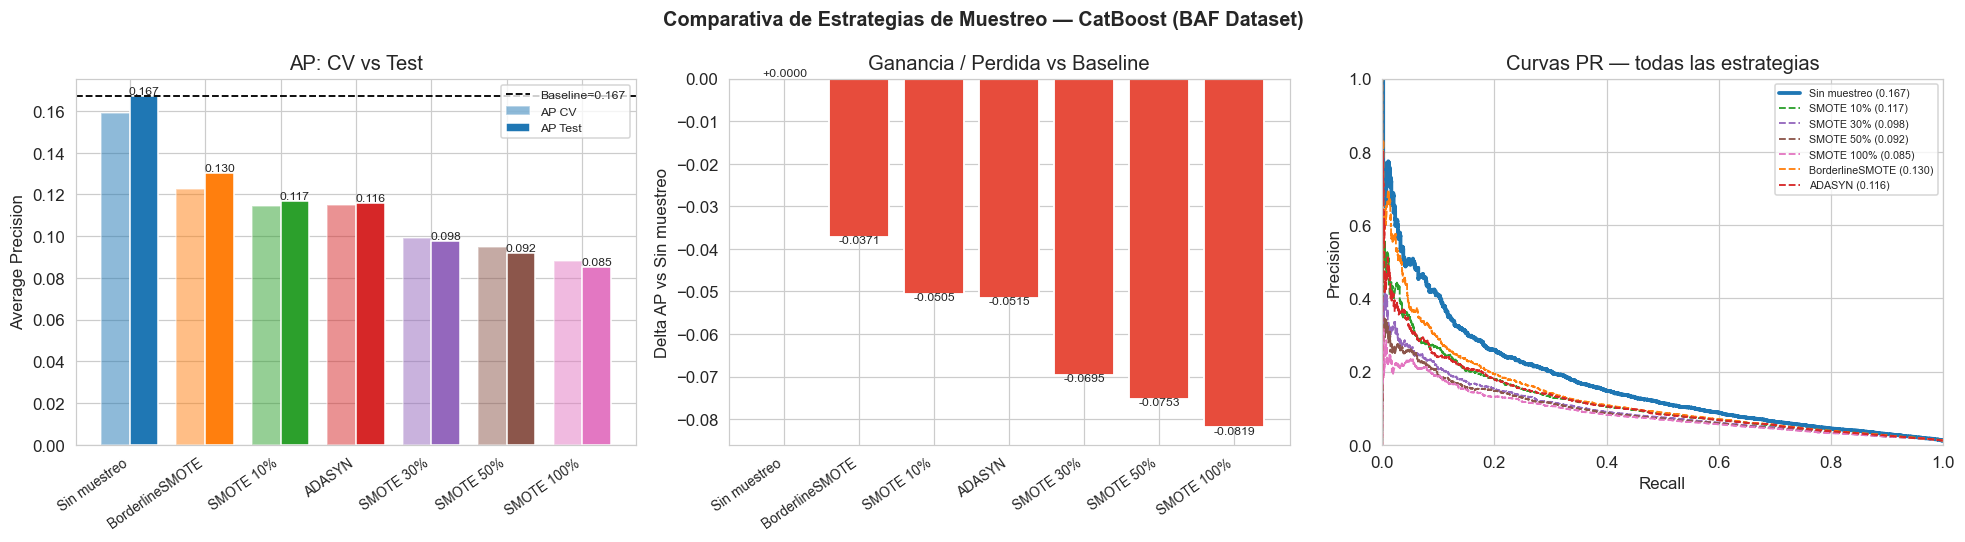

Grafico guardado: estrategias_muestreo.png


In [14]:
estrategias = df_res['Estrategia'].tolist()
palette     = sns.color_palette('tab10', len(estrategias))
color_map   = dict(zip(estrategias, palette))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparativa de Estrategias de Muestreo — CatBoost (BAF Dataset)',
             fontsize=13, fontweight='bold')

# AP CV vs AP Test
ax = axes[0]
x, w = np.arange(len(estrategias)), 0.38
ax.bar(x - w/2, df_res['AP_CV'], width=w, label='AP CV',
       color=[color_map[e] for e in estrategias], alpha=0.5, edgecolor='white')
bars = ax.bar(x + w/2, df_res['AP_test'], width=w, label='AP Test',
              color=[color_map[e] for e in estrategias], alpha=1.0, edgecolor='white')
ax.axhline(baseline_ap, color='black', linestyle='--', linewidth=1.2,
           label=f'Baseline={baseline_ap:.3f}')
ax.set_xticks(x); ax.set_xticklabels(estrategias, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Average Precision'); ax.set_title('AP: CV vs Test')
ax.legend(fontsize=8)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.3f}', ha='center', fontsize=8)

# Ganancia vs baseline
ax = axes[1]
delta = df_res['vs_baseline'].tolist()
bar_colors = ['#27ae60' if d > 0 else ('#e74c3c' if d < 0 else '#95a5a6') for d in delta]
bars2 = ax.bar(estrategias, delta, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.axhline(0, color='black', linewidth=1)
for b in bars2:
    yoff = 0.0005 if b.get_height() >= 0 else -0.0015
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+yoff,
            f'{b.get_height():+.4f}', ha='center', fontsize=8)
ax.set_xticklabels(estrategias, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Delta AP vs Sin muestreo')
ax.set_title('Ganancia / Perdida vs Baseline')

# Curvas PR
ax = axes[2]
for r in results:
    e = r['Estrategia']
    prec_c, rec_c, _ = precision_recall_curve(y_test, r['_y_proba'])
    lw = 2.5 if e == winner else 1.2
    ls = '-'  if e == winner else '--'
    ax.plot(rec_c, prec_c, label=f"{e} ({r['AP_test']:.3f})",
            linewidth=lw, linestyle=ls, color=color_map[e])
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas PR — todas las estrategias')
ax.legend(fontsize=7, loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig('estrategias_muestreo.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafico guardado: estrategias_muestreo.png')


Ahora se geenera una segunda figura con diseño más elaborado, también con 3 subplots:  
1. **La paradoja del SMOTE** — gráfico de puntos que muestra cómo el AP desciende al aumentar el ratio de SMOTE.  
2. **Impacto real vs baseline** — barras horizontales divergentes para leer fácilmente qué estrategias pierden rendimiento.  
3. **Coste computacional vs calidad** — scatter de Tiempo vs AP dividido en cuadrantes (rápido+preciso = ganador).  

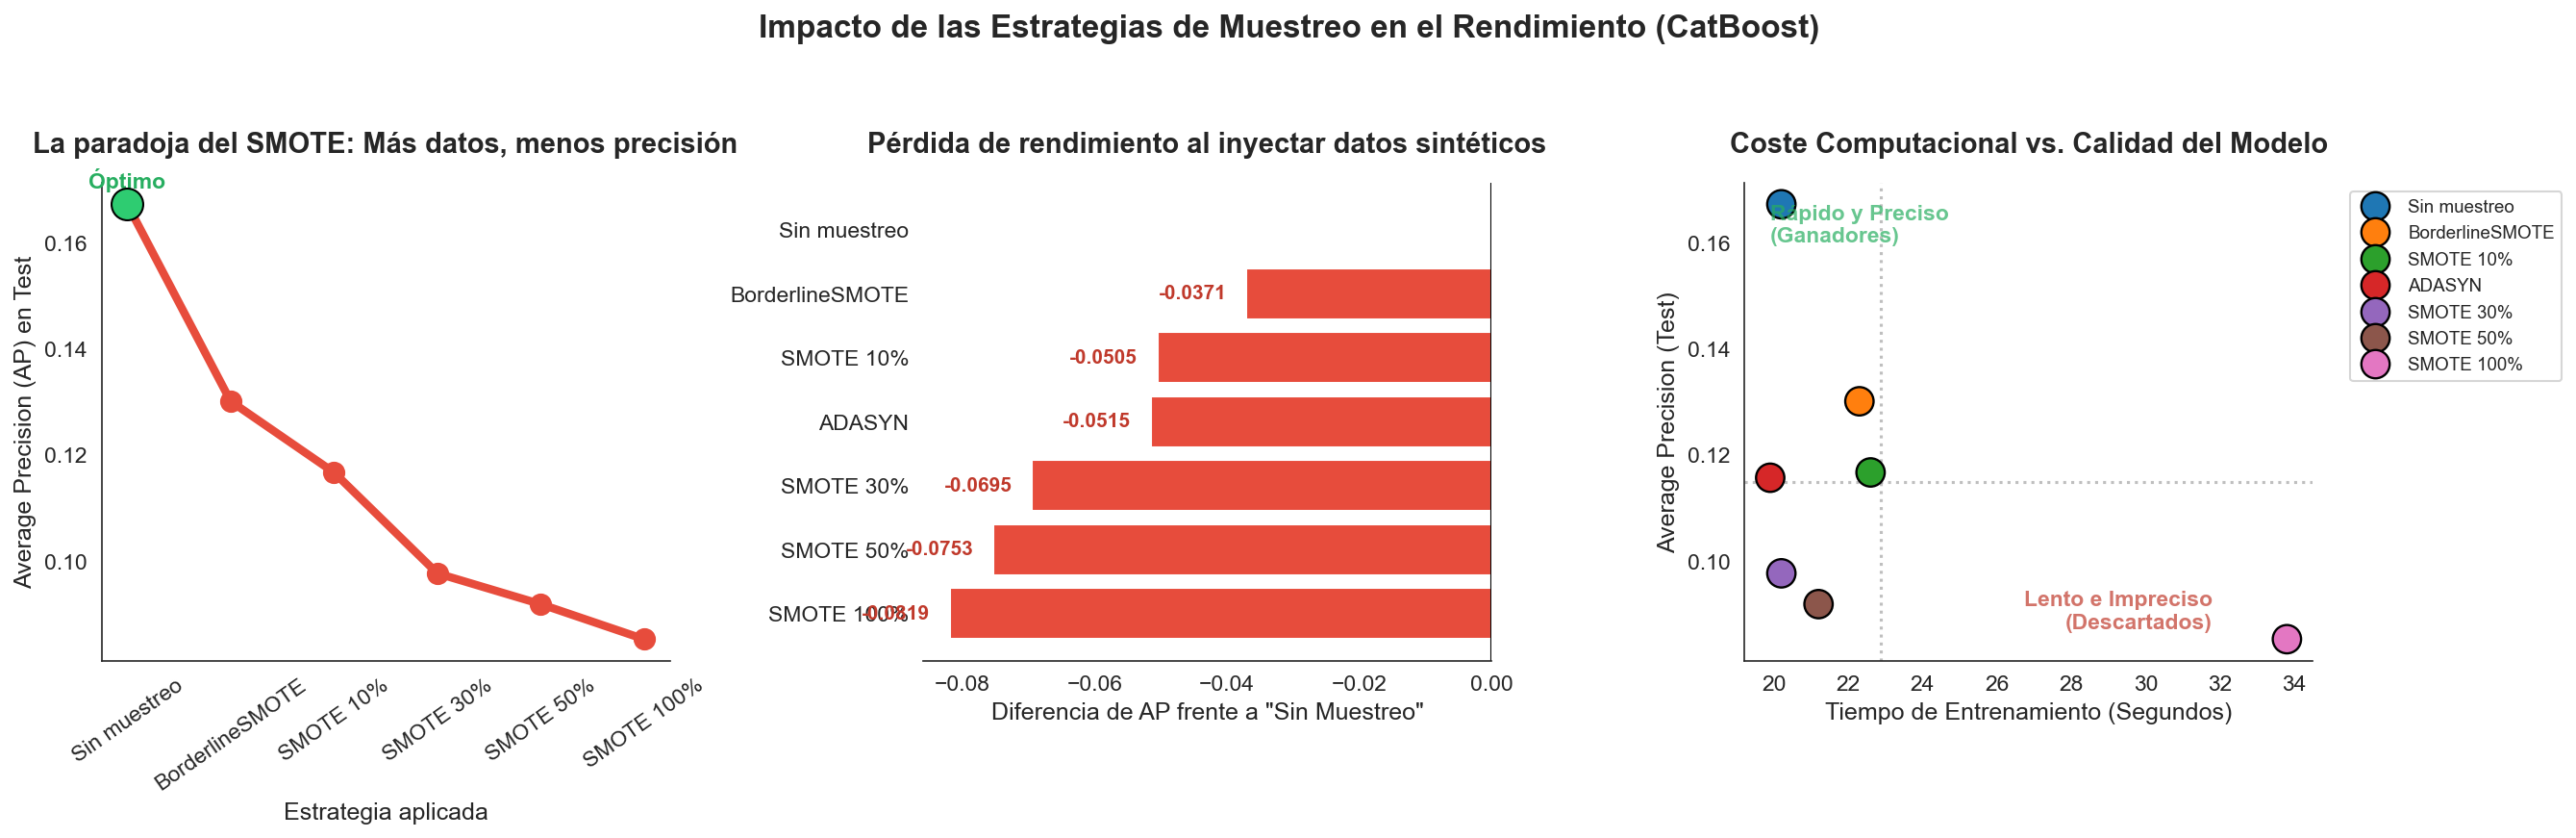

Gráfico premium guardado: estrategias_muestreo_nueva.png


In [15]:
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})
sns.set_style("white")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Impacto de las Estrategias de Muestreo en el Rendimiento (CatBoost)', 
             fontsize=16, fontweight='bold', y=1.05)


# El efecto degradante de SMOTE (Línea de tendencia)
ax = axes[0]
# Filtramos solo las estrategias que son porcentajes de SMOTE + Sin muestreo
smote_trends = df_res[df_res['Estrategia'].str.contains('SMOTE|Sin muestreo')].copy()

sns.pointplot(data=smote_trends, x='Estrategia', y='AP_test', 
              color='#e74c3c', markers='o', scale=1.5, ax=ax)

# Resaltar el punto óptimo (Sin muestreo)
sin_muestreo_ap = df_res.loc[df_res['Estrategia'] == 'Sin muestreo', 'AP_test'].values[0]
ax.scatter(0, sin_muestreo_ap, color='#2ecc71', s=250, zorder=5, edgecolors='black')
ax.text(0, sin_muestreo_ap + 0.003, 'Óptimo', color='#27ae60', fontweight='bold', ha='center')

ax.set_title('La paradoja del SMOTE: Más datos, menos precisión', fontweight='bold', pad=15)
ax.set_ylabel('Average Precision (AP) en Test')
ax.set_xlabel('Estrategia aplicada')
ax.tick_params(axis='x', rotation=35)
sns.despine(ax=ax)

# Impacto real vs baseline (Gráfico de Barras Divergentes Horizontal)
ax = axes[1]
# Ordenar de mejor a peor para que sea súper legible
df_sorted = df_res.sort_values('vs_baseline', ascending=True)

colores = ['#e74c3c' if val < 0 else '#2ecc71' for val in df_sorted['vs_baseline']]
bars = ax.barh(df_sorted['Estrategia'], df_sorted['vs_baseline'], color=colores, edgecolor='white')

# Línea base (0)
ax.axvline(0, color='black', linewidth=1.5)

# Poner los números al lado de cada barra
for bar in bars:
    ancho = bar.get_width()
    x_pos = ancho - 0.003 if ancho < 0 else ancho + 0.001
    alineacion = 'right' if ancho < 0 else 'left'
    color_texto = '#c0392b' if ancho < 0 else '#27ae60'
    
    if ancho != 0: # Evitar poner +0.0000 en el baseline
        ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{ancho:+.4f}', 
                va='center', ha=alineacion, color=color_texto, fontweight='bold', fontsize=10)

ax.set_title('Pérdida de rendimiento al inyectar datos sintéticos', fontweight='bold', pad=15)
ax.set_xlabel('Diferencia de AP frente a "Sin Muestreo"')
ax.set_ylabel('')
sns.despine(ax=ax, left=True)

# Matriz de eficiencia: Tiempo vs Rendimiento (Scatter con cuadrantes)
ax = axes[2]

# Queremos que lo óptimo esté arriba a la izquierda (Alto AP, Bajo Tiempo)
sns.scatterplot(data=df_res, x='Tiempo_s', y='AP_test', 
                hue='Estrategia', s=200, palette='tab10', ax=ax, edgecolor='black', zorder=3)

# Dibujar cuadrantes (líneas en la media)
ax.axhline(df_res['AP_test'].mean(), color='gray', linestyle=':', alpha=0.5)
ax.axvline(df_res['Tiempo_s'].mean(), color='gray', linestyle=':', alpha=0.5)

# Textos para los cuadrantes
ax.text(df_res['Tiempo_s'].min(), df_res['AP_test'].max(), 'Rápido y Preciso\n(Ganadores)', 
        color='#27ae60', fontweight='bold', alpha=0.7, va='top')
ax.text(df_res['Tiempo_s'].max() - 2, df_res['AP_test'].min() + 0.002, 'Lento e Impreciso\n(Descartados)', 
        color='#c0392b', fontweight='bold', alpha=0.7, ha='right')

ax.set_title('Coste Computacional vs. Calidad del Modelo', fontweight='bold', pad=15)
ax.set_xlabel('Tiempo de Entrenamiento (Segundos)')
ax.set_ylabel('Average Precision (Test)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('estrategias_muestreo_premium.png', bbox_inches='tight', facecolor='white')
plt.show()
print('Gráfico premium guardado: estrategias_muestreo_nueva.png')